In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [4]:
# Loading the cleaning  data 
df_clean = pd.read_csv(r"C:\Users\ElMo7trf\Desktop\Nti Project1\employee_attrition_analysis\data\processed\IBM_HR_Attrition_Cleaned.csv")
df_clean.head()  

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,RecordID
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,4945.5,19479,8,Yes,11,3,1,0,8.0,0,1,6.0,4,0,5,100001
1,49,No,Travel_Frequently,279,Research and Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,4945.5,24907,1,No,23,4,4,1,10.0,3,3,10.0,7,1,7,100002
2,37,Yes,Travel_Rarely,1373,Research and Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090.0,2396,6,Yes,15,3,2,0,7.0,3,3,0.0,0,0,0,100003
3,33,No,Travel_Frequently,1392,Research and Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909.0,23159,1,Yes,11,3,3,0,8.0,3,3,5.0,7,3,0,100004
4,27,No,Travel_Rarely,591,Research and Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468.0,16632,9,No,12,3,4,1,6.0,3,3,2.0,2,2,2,100005


In [5]:
# Check the shape 
df_clean.shape

(1470, 33)

In [6]:
# Feature Engineering
# Create additional features that may improve employee behavior analysis
# and predictive model performance.

# 1. Income per Working Year
# Estimate income relative to total professional experience.
df_clean['IncomePerWorkingYear'] = (
    df_clean['MonthlyIncome'] /
    (df_clean['TotalWorkingYears'] + 1)
)


# 2. Experience Level
# Categorize employees based on their total working experience.
def experience_level(years):
    if years <= 3:
        return "Junior"
    elif years <= 10:
        return "Mid"
    else:
        return "Senior"


df_clean['ExperienceLevel'] = df_clean['TotalWorkingYears'].apply(
    experience_level
)


# 3. Promotion Rate
# Measure promotion frequency relative to tenure in the company.
df_clean['PromotionRate'] = (
    df_clean['YearsSinceLastPromotion'] /
    (df_clean['YearsAtCompany'] + 1)
)


# 4. Tenure Group
# Categorize employees based on years spent in the company.
def tenure_group(years):
    if years <= 1:
        return "0–1 Years"
    elif years <= 3:
        return "1–3 Years"
    elif years <= 5:
        return "3–5 Years"
    else:
        return "5+ Years"


df_clean['TenureGroup'] = df_clean['YearsAtCompany'].apply(
    tenure_group
)


# 5. High Income Indicator
# Flag employees whose income exceeds the dataset median.
median_income = df_clean['MonthlyIncome'].median()

df_clean['HighIncomeIndicator'] = (
    df_clean['MonthlyIncome'] > median_income
).astype(int)


print("Five engineered features were created successfully.")

df_clean[
    [
        "IncomePerWorkingYear",
        "ExperienceLevel",
        "PromotionRate",
        "TenureGroup",
        "HighIncomeIndicator"
    ]
].head()

Five engineered features were created successfully.


,IncomePerWorkingYear,ExperienceLevel,PromotionRate,TenureGroup,HighIncomeIndicator
0,549.500000,Mid,0.000000,5+ Years,0
1,449.590909,Mid,0.090909,5+ Years,0
2,261.250000,Mid,0.000000,0–1 Years,0
3,323.222222,Mid,0.500000,3–5 Years,0
4,495.428571,Mid,0.666667,1–3 Years,0


### Business Value of the Engineered Features

| Engineered Feature | Business Value |
|---|---|
| **IncomePerWorkingYear** | Highlights employees whose compensation is relatively low compared to their professional experience, which may indicate a higher risk of attrition due to perceived underpayment. |
| **ExperienceLevel** | Groups employees into meaningful career stages (Junior, Mid, Senior), enabling clearer comparisons of attrition patterns than using raw years of experience alone. |
| **PromotionRate** | Identifies employees with slower promotion progression, helping detect potential career stagnation that may contribute to voluntary turnover. |
| **TenureGroup** | Captures different stages of an employee's lifecycle within the company, allowing analysis of how attrition varies across tenure groups rather than assuming a linear relationship. |
| **HighIncomeIndicator** | Provides a simple binary indicator for comparing behavioral patterns and attrition rates between higher- and lower-income employee groups. |

In [7]:
# Encoding & Scaling
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Create a copy of the cleaned dataset for preprocessing
df_encoded = df_clean.copy()

# Encode the target variable
# Attrition: Yes -> 1, No -> 0
df_encoded["Attrition"] = df_encoded["Attrition"].map({
    "Yes": 1,
    "No": 0
})

# Identify categorical features (excluding the target variable)
categorical_cols = df_encoded.select_dtypes(
    include="object"
).columns.tolist()

print("Categorical features:")
print(categorical_cols)

Categorical features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'ExperienceLevel', 'TenureGroup']


In [8]:
# Apply One-Hot Encoding to nominal categorical features
# These variables have no natural ordering, so One-Hot Encoding is used
# to avoid introducing artificial ordinal relationships.

nominal_cols = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime",
    "ExperienceLevel",
    "TenureGroup"
]

df_encoded = pd.get_dummies(
    df_encoded,
    columns=nominal_cols,
    drop_first=True,
    dtype=int
)

print("Dataset shape after One-Hot Encoding:", df_encoded.shape)

Dataset shape after One-Hot Encoding: (1470, 55)


In [9]:
# Standardize continuous numerical features
# StandardScaler transforms each feature to have a mean of approximately 0
# and a standard deviation of approximately 1.

numeric_features = [
    "DailyRate",
    "DistanceFromHome",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "IncomePerWorkingYear",
    "PromotionRate"
]

scaler = StandardScaler()

df_scaled = df_encoded.copy()

df_scaled[numeric_features] = scaler.fit_transform(
    df_encoded[numeric_features]
)

print("StandardScaler applied successfully.")

df_scaled[numeric_features].describe().T[["mean", "std"]]

StandardScaler applied successfully.


,mean,std
DailyRate,5.075305e-17,1.00034
DistanceFromHome,1.933450e-17,1.00034
HourlyRate,1.691768e-16,1.00034
MonthlyIncome,7.250436e-17,1.00034
MonthlyRate,3.021015e-17,1.00034
TotalWorkingYears,8.821364e-17,1.00034
YearsAtCompany,4.833624e-17,1.00034
YearsInCurrentRole,9.063045e-17,1.00034
YearsSinceLastPromotion,1.208406e-18,1.00034
YearsWithCurrManager,-2.779334e-17,1.00034


## Business Question 1

### Does Working Overtime Increase Employee Attrition?

Employee overtime is often associated with increased workload, higher stress levels, and reduced work-life balance. These factors may negatively affect employee satisfaction and increase the likelihood of voluntary turnover.

In this analysis, we investigate whether employees who work overtime experience a higher attrition rate than those who do not. The objective is to determine whether overtime is a significant factor influencing employee retention and whether workload management should be considered a strategic priority for the Human Resources department.

Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


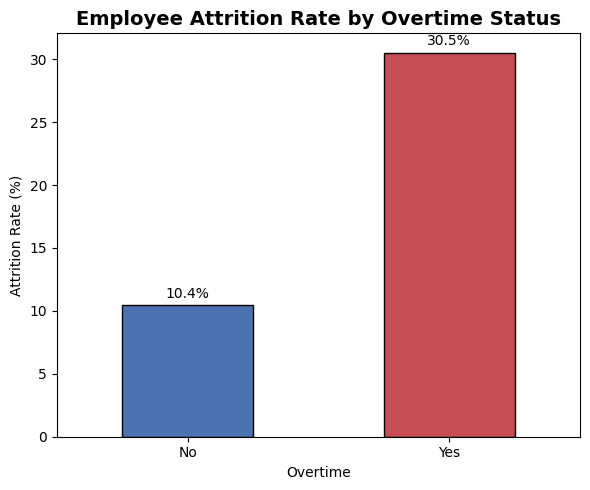

In [10]:
# Calculate the attrition rate for employees with and without overtime

overtime_attrition = (
    pd.crosstab(
        df_clean["OverTime"],
        df_clean["Attrition"],
        normalize="index"
    ) * 100
).round(2)

display(overtime_attrition)

# Visualization
fig, ax = plt.subplots(figsize=(6, 5))

overtime_attrition["Yes"].plot(
    kind="bar",
    ax=ax,
    color=["#4C72B0", "#C44E52"],
    edgecolor="black"
)

ax.set_title(
    "Employee Attrition Rate by Overtime Status",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Overtime")
ax.set_ylabel("Attrition Rate (%)")
ax.set_xticklabels(["No", "Yes"], rotation=0)

# Display percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

> **Hypothesis:** Employees who frequently work overtime are expected to have a higher attrition rate due to increased workload, stress, and potential burnout.

> **Business Insight:** If the attrition rate for employees working overtime (`Yes`) is noticeably higher than for those not working overtime (`No`), this would support the hypothesis that overtime is associated with employee turnover. In such a case, the Human Resources department should consider reviewing overtime policies, balancing workloads, and promoting work-life balance initiatives to improve employee retention.

#### Does monthly income affect leaving a job?


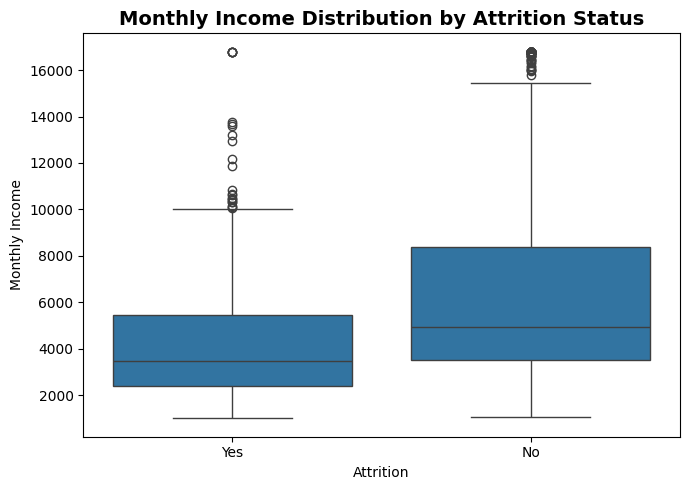

Median Monthly Income:
Attrition
No     4945.5
Yes    3485.0
Name: MonthlyIncome, dtype: float64


In [11]:
# Compare the distribution of monthly income
# between employees who stayed and those who left.

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="MonthlyIncome",
    ax=ax
)

ax.set_title(
    "Monthly Income Distribution by Attrition Status",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Attrition")
ax.set_ylabel("Monthly Income")

plt.tight_layout()
plt.show()

# Median monthly income by attrition status
monthly_income_summary = (
    df_clean
    .groupby("Attrition")["MonthlyIncome"]
    .median()
    .round(2)
)

print("Median Monthly Income:")
print(monthly_income_summary)

> **Business Insight:** If the median monthly income of employees in the **Attrition = Yes** group is noticeably lower than that of employees in the **Attrition = No** group, this suggests that lower compensation may be an important factor contributing to employee turnover. This relationship may be particularly pronounced among employees in entry-level and lower-career-stage positions, where compensation is often a stronger driver of retention.

##### Which departments suffer the most from employee turnover?

Attrition,No,Yes
Department,,
Sales,79.37,20.63
Human Resources,80.95,19.05
Research and Development,86.16,13.84


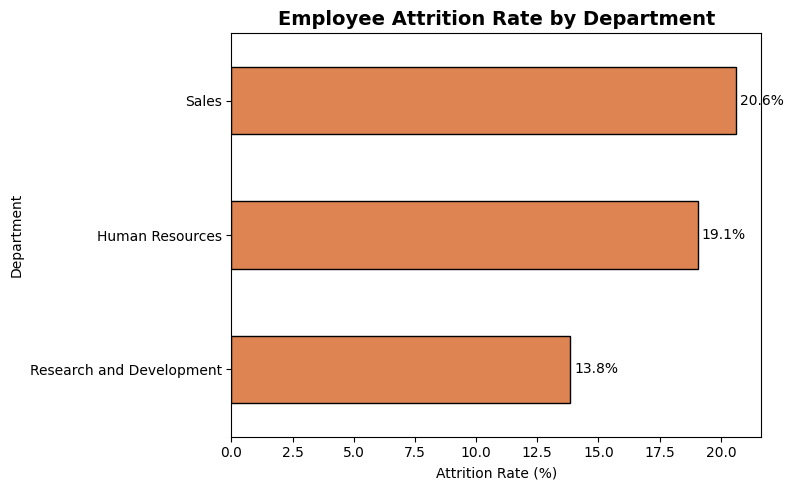

In [13]:
# Calculate the attrition rate for each department
department_attrition = (
    pd.crosstab(
        df_clean["Department"],
        df_clean["Attrition"],
        normalize="index"
    )
    .mul(100)
    .round(2)
    .sort_values(by="Yes", ascending=False)
)

display(department_attrition)

# Visualize the attrition rate by department
fig, ax = plt.subplots(figsize=(8, 5))

department_attrition["Yes"].plot(
    kind="barh",
    ax=ax,
    color="#DD8452",
    edgecolor="black"
)

ax.set_title(
    "Employee Attrition Rate by Department",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("Department")

# Display percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

ax.invert_yaxis()  # Highest attrition at the top

plt.tight_layout()
plt.show()

#### Does employee job satisfaction reduce the likelihood of them leaving their job?

Attrition,No,Yes
JobSatisfaction,,
1,77.16,22.84
2,83.57,16.43
3,83.48,16.52
4,88.67,11.33


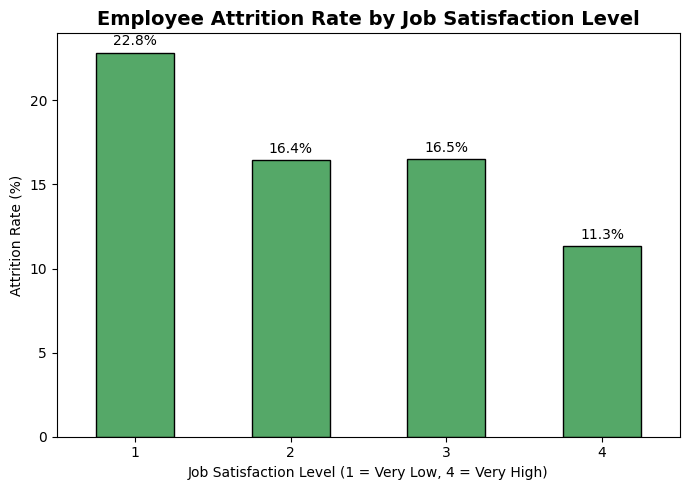

In [14]:
# Calculate the attrition rate by job satisfaction level
job_satisfaction_attrition = (
    pd.crosstab(
        df_clean["JobSatisfaction"],
        df_clean["Attrition"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

display(job_satisfaction_attrition)

# Visualize the attrition rate across job satisfaction levels
fig, ax = plt.subplots(figsize=(7, 5))

job_satisfaction_attrition["Yes"].plot(
    kind="bar",
    ax=ax,
    color="#55A868",
    edgecolor="black"
)

ax.set_title(
    "Employee Attrition Rate by Job Satisfaction Level",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Job Satisfaction Level (1 = Very Low, 4 = Very High)")
ax.set_ylabel("Attrition Rate (%)")
ax.set_xticklabels(["1", "2", "3", "4"], rotation=0)

# Display percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

#### What are the high-risk categories (High-Risk Segments)?

In [15]:
# Identify employees with multiple attrition risk factors
high_risk_group = df_clean[
    (df_clean["OverTime"] == "Yes") &
    (df_clean["JobLevel"] <= 2) &
    (df_clean["JobSatisfaction"] <= 2)
]

# Calculate attrition rates
high_risk_attrition_rate = (
    high_risk_group["Attrition"]
    .eq("Yes")
    .mean() * 100
)

overall_attrition_rate = (
    df_clean["Attrition"]
    .eq("Yes")
    .mean() * 100
)

# Summary
print(f"High-Risk Group Size: {len(high_risk_group)} employees")
print(f"High-Risk Attrition Rate: {high_risk_attrition_rate:.2f}%")
print(f"Overall Company Attrition Rate: {overall_attrition_rate:.2f}%")
print(
    f"Difference: "
    f"{high_risk_attrition_rate - overall_attrition_rate:.2f} percentage points"
)

High-Risk Group Size: 110 employees
High-Risk Attrition Rate: 38.18%
Overall Company Attrition Rate: 16.12%
Difference: 22.06 percentage points


# Feature Selection

In [16]:
# Separate features and target variable
# Remove identifier columns since they do not provide predictive information.

X = df_scaled.drop(
    columns=[
        "Attrition",
        "EmployeeNumber",
        "RecordID"
    ]
)

y = df_scaled["Attrition"]

print(f"Number of features before feature selection: {X.shape[1]}")
print(f"Number of observations: {X.shape[0]}")

Number of features before feature selection: 52
Number of observations: 1470


In [17]:
# Correlation Matrix between Digital Features and Target

# Compute the correlation of each feature with the target variable
correlation_with_target = (
    df_encoded
    .drop(columns=["EmployeeNumber", "RecordID"])
    .corr(numeric_only=True)["Attrition"]
    .sort_values(ascending=False)
)

display(correlation_with_target)

Attrition                              1.000000
OverTime_Yes                           0.246118
MaritalStatus_Single                   0.175419
JobRole_Sales Representative           0.157234
BusinessTravel_Travel_Frequently       0.115143
JobRole_Laboratory Technician          0.093207
Department_Sales                       0.080855
DistanceFromHome                       0.079538
EducationField_Technical Degree        0.069298
IncomePerWorkingYear                   0.064095
EducationField_Marketing               0.052034
NumCompaniesWorked                     0.043494
TenureGroup_1–3 Years                  0.039186
Gender_Male                            0.029453
JobRole_Human Resources                0.028077
JobRole_Sales Executive                0.020515
PromotionRate                          0.016478
MonthlyRate                            0.015170
PerformanceRating                      0.002889
JobRole_Research Scientist             0.002644
HourlyRate                            -0

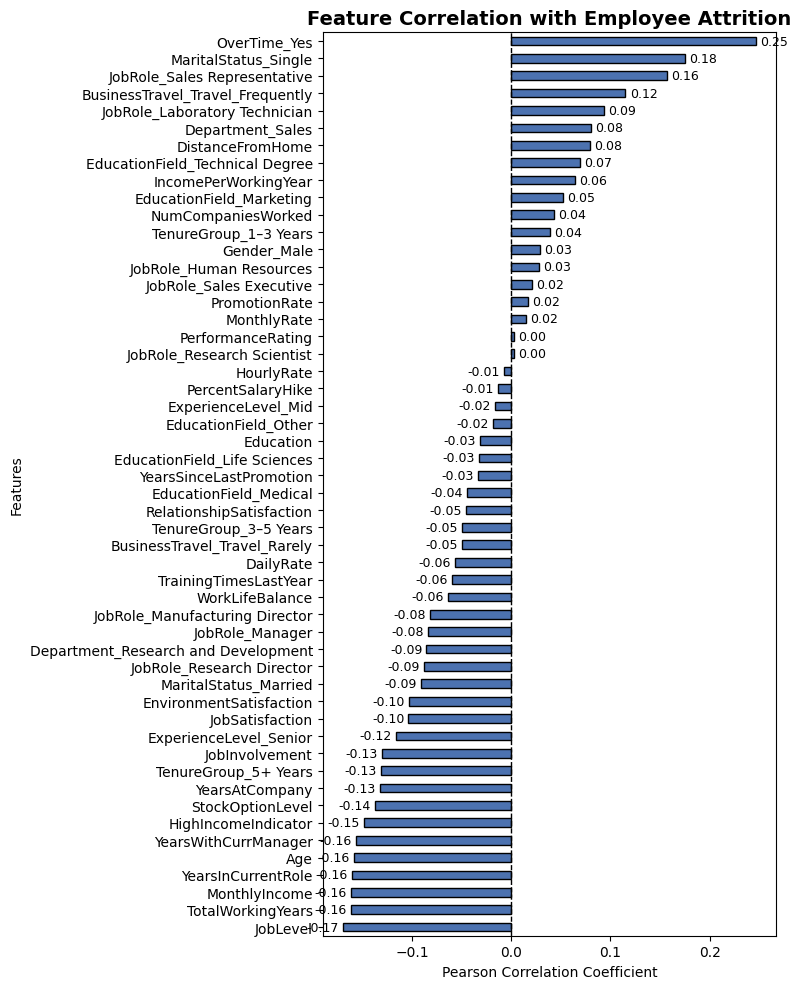

In [18]:
# Visualize the correlation of each feature with the target variable
feature_correlations = (
    correlation_with_target
    .drop("Attrition")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 10))

feature_correlations.plot(
    kind="barh",
    ax=ax,
    color="#4C72B0",
    edgecolor="black"
)

ax.set_title(
    "Feature Correlation with Employee Attrition",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Pearson Correlation Coefficient")
ax.set_ylabel("Features")

# Add a reference line at zero
ax.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1
)

# Display correlation values beside each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [19]:
# Chi-Square test for categorical features (Categorical vs Target)
from sklearn.feature_selection import chi2

# Select binary one-hot encoded features
binary_features = [
    column
    for column in X.columns
    if X[column].nunique() == 2
    and set(X[column].unique()) <= {0, 1, True, False}
]

X_binary = X[binary_features].astype(int)

# Compute Chi-Square statistics
chi2_scores, p_values = chi2(X_binary, y)

# Create a summary table
chi2_results = (
    pd.DataFrame({
        "Feature": binary_features,
        "Chi-Square Score": chi2_scores,
        "P-Value": p_values
    })
    .sort_values(by="Chi-Square Score", ascending=False)
    .reset_index(drop=True)
)

display(chi2_results.head(15))

,Feature,Chi-Square Score,P-Value
0,OverTime_Yes,63.845067,1.345990e-15
1,JobRole_Sales Representative,34.290268,4.747499e-09
2,MaritalStatus_Single,30.771669,2.902446e-08
3,HighIncomeIndicator,17.491643,2.885734e-05
4,BusinessTravel_Travel_Frequently,15.816623,6.978671e-05
5,TenureGroup_5+ Years,13.789209,2.045075e-04
6,ExperienceLevel_Senior,12.772295,3.517909e-04
7,JobRole_Research Director,10.790476,1.020236e-03
8,JobRole_Laboratory Technician,10.564111,1.153045e-03
9,JobRole_Manager,9.496136,2.059051e-03


### Interpretation

The **Chi-Square score** measures the strength of the statistical association between a categorical feature and the target variable (**Attrition**).

- A **higher Chi-Square score** indicates a stronger relationship between the feature and employee attrition.
- A **p-value less than 0.05** indicates that the observed association is statistically significant and unlikely to have occurred by chance.

Therefore, features with **high Chi-Square scores** and **low p-values** are considered the most informative categorical predictors of employee attrition and should be prioritized during feature selection.

In [21]:
#Mutual Information — to capture nonlinear relationships
from sklearn.feature_selection import mutual_info_classif

# Compute Mutual Information scores
mutual_information_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

# Create a summary table
mi_results = (
    pd.DataFrame({
        "Feature": X.columns,
        "Mutual Information Score": mutual_information_scores
    })
    .sort_values(
        by="Mutual Information Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(mi_results.head(20))

,Feature,Mutual Information Score
0,MonthlyIncome,0.027829
1,OverTime_Yes,0.027769
2,Age,0.025197
3,YearsInCurrentRole,0.022581
4,JobRole_Sales Representative,0.021853
5,TenureGroup_5+ Years,0.021538
6,JobLevel,0.019727
7,HighIncomeIndicator,0.018385
8,Department_Sales,0.016929
9,YearsAtCompany,0.015099


### Why Mutual Information?

Pearson correlation measures only **linear relationships** between features and the target variable. However, many real-world HR factors influence employee attrition in more complex ways that may not follow a linear pattern.

**Mutual Information** measures the amount of information a feature provides about the target, allowing it to capture both **linear and non-linear relationships**. This makes it particularly valuable for HR analytics, where employee turnover is often driven by complex interactions among multiple factors.

As a result, Mutual Information can identify informative features that traditional correlation analysis may overlook.

In [22]:
# Select the top features based on Mutual Information scores
top_k = 15

top_features = (
    mi_results
    .head(top_k)["Feature"]
    .tolist()
)

print(f"Top {top_k} Features Selected by Mutual Information")
print("-" * 50)

for feature in top_features:
    print(f"• {feature}")

Top 15 Features Selected by Mutual Information
--------------------------------------------------
• MonthlyIncome
• OverTime_Yes
• Age
• YearsInCurrentRole
• JobRole_Sales Representative
• TenureGroup_5+ Years
• JobLevel
• HighIncomeIndicator
• Department_Sales
• YearsAtCompany
• StockOptionLevel
• TotalWorkingYears
• PromotionRate
• JobRole_Manager
• TenureGroup_3–5 Years


In [24]:
# Save the cleaned dataset and the final feature set

final_dataset = df_scaled[
    top_features + ["Attrition"]
]

# Export datasets
final_dataset.to_csv(
    r"C:\Users\ElMo7trf\Desktop\Nti Project1\employee_attrition_analysis\data\processed\employee_attrition_features_selected.csv",
    index=False
)
df_clean.to_csv(
    r"C:\Users\ElMo7trf\Desktop\Nti Project1\employee_attrition_analysis\data\processed\employee_attrition_cleaned.csv",
    index=False
)

print("=" * 60)
print("Datasets Successfully Saved")
print("=" * 60)

print("employee_attrition_cleaned.csv")
print("  Cleaned dataset after preprocessing and feature engineering.")

print("\nemployee_attrition_features_selected.csv")
print("  Final dataset containing the selected features and target variable.")

print(f"\nFinal Dataset Shape: {final_dataset.shape}")

display(final_dataset.head())

Datasets Successfully Saved
employee_attrition_cleaned.csv
  Cleaned dataset after preprocessing and feature engineering.

employee_attrition_features_selected.csv
  Final dataset containing the selected features and target variable.

Final Dataset Shape: (1470, 16)


,MonthlyIncome,OverTime_Yes,Age,YearsInCurrentRole,JobRole_Sales Representative,TenureGroup_5+ Years,JobLevel,HighIncomeIndicator,Department_Sales,YearsAtCompany,StockOptionLevel,TotalWorkingYears,PromotionRate,JobRole_Manager,TenureGroup_3–5 Years,Attrition
0,-0.324686,1,41,-0.063296,0,1,2,0,1,-0.158926,0,-0.421766,-0.849674,0,0,1
1,-0.324686,0,49,0.764998,0,1,2,0,0,0.501487,1,-0.160660,-0.528460,0,0,0
2,-0.992603,1,37,-1.167687,0,0,1,0,0,-1.149546,0,-0.552319,-0.849674,0,0,1
3,-0.801034,1,33,0.764998,0,0,1,0,0,-0.324029,0,-0.421766,0.917003,0,1,0
4,-0.670281,0,27,-0.615492,0,0,1,0,0,-0.819339,1,-0.682873,1.505895,0,0,0


---
# Notebook Summary

This notebook successfully completed the **Data Preparation** and **Exploratory Data Analysis (EDA)** phases of the IBM HR Analytics Employee Attrition project.

### Completed Tasks

- Performed a comprehensive **data quality assessment**, identifying and resolving **13 data quality issues**.
- Cleaned and preprocessed the dataset, with every decision documented and justified.
- Applied **categorical encoding** and **feature scaling** to prepare the data for machine learning.
- Conducted a comprehensive **Exploratory Data Analysis (EDA)** to answer key business questions related to employee attrition.
- Engineered **five new features** to enhance the dataset with additional business insights.
- Selected the most informative features using three complementary feature selection techniques:
  - **Pearson Correlation**
  - **Chi-Square Test**
  - **Mutual Information**

### Deliverables

The following datasets were generated during this notebook:

- **`employee_attrition_cleaned.csv`** – Cleaned dataset after preprocessing and feature engineering, before categorical encoding.
- **`employee_attrition_features_selected.csv`** – Final machine learning dataset containing the selected features and the target variable, ready for model development.

---

## Next Step

The next phase of the project, implemented in a separate notebook, will focus on **Machine Learning Model Development**. This includes:

- Splitting the data into training and testing sets.
- Training multiple classification models to predict employee attrition.
- Evaluating model performance using appropriate classification metrics.
- Comparing different algorithms to identify the best-performing model.
- Interpreting feature importance and translating model results into actionable HR recommendations.